# Task 2b — Detector Domain Adaptation (Fine-tuning)

**Problem:** YOLOv8s trained on OmniCrack30k (34.6% mAP@50) collapses on CrackForest (4.8%) and Masonry (1.1%) due to domain gap — OmniCrack images are large-scale pavement/concrete cracks; target datasets have fine, structured heritage cracks.

**Fix:** Fine-tune from OmniCrack30k checkpoint on CrackForest + Masonry combined.

| | OmniCrack30k test | CrackForest | Masonry |
|--|--|--|--|
| Before fine-tuning | 34.6% | 4.8% | 1.1% |
| After fine-tuning | — (not re-evaluated) | **28.4%** | **23.1%** |

**Runtime required:** T4 GPU (`Runtime > Change runtime type > T4 GPU`)

In [1]:
import torch
assert torch.cuda.is_available(), "No GPU — Runtime > Change runtime type > T4 GPU"
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

GPU   : Tesla T4
VRAM  : 15.6 GB
PyTorch: 2.10.0+cu128


In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.6 MB/s eta 0:00:00


## 1. Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import zipfile, shutil, json

DRIVE_DIR = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR  = Path('/content/data')
CKPT_DIR  = Path('/content/checkpoints/detector_ft')
OUT_DIR   = Path('/content/detector_ft')

for d in [DATA_DIR, CKPT_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Drive contents:")
for f in sorted(DRIVE_DIR.iterdir()):
    print(f"  {f.name}")

Mounted at /content/drive
Drive contents:
  checkpoints
  crackforest.zip
  cross_eval
  failure_analysis
  historical_crack.zip
  masonry.zip
  notebooks
  omnicrack30k.zip
  plots
  samples


In [4]:
for zip_name, out_name in [
    ('crackforest.zip', 'crackforest'),
    ('masonry.zip',     'masonry'),
]:
    out_dir = DATA_DIR / out_name
    if out_dir.exists() and any(out_dir.rglob('*.*')):
        print(f"{out_name}: already extracted")
    else:
        print(f"Unzipping {zip_name}...")
        with zipfile.ZipFile(DRIVE_DIR / zip_name) as zf:
            zf.extractall(DATA_DIR)
        print("  Done.")

# Copy base detector checkpoint
base_ckpt_src = DRIVE_DIR / 'checkpoints' / 'detector' / 'best.pt'
base_ckpt_dst = Path('/content/base_detector.pt')
if not base_ckpt_dst.exists():
    print("Copying base detector checkpoint...")
    shutil.copy2(base_ckpt_src, base_ckpt_dst)
    print(f"  Done  ({base_ckpt_dst.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Base detector: already local")

for name, path in [
    ('crackforest/images', DATA_DIR / 'crackforest' / 'images'),
    ('masonry/images',     DATA_DIR / 'masonry' / 'images'),
]:
    n = len(list(Path(path).glob('*.*'))) if Path(path).exists() else 0
    print(f"{name}: {n} images")

Unzipping crackforest.zip...
  Done.
Unzipping masonry.zip...
  Done.
Copying base detector checkpoint...
  Done  (22.5 MB)
crackforest/images: 118 images
masonry/images: 240 images


## 2. Build Fine-tuning Dataset

In [5]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

YOLO_DIR = Path('/content/yolo_finetune')
SEED     = 42


def mask_to_yolo_labels(mask_path, min_area=200, max_aspect=4, n_segments=3):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    h, w = mask.shape
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    labels = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        aspect = max(bw, bh) / (min(bw, bh) + 1e-6)
        if aspect > max_aspect:
            # split long crack along dominant axis — tighter boxes, less background
            if bw >= bh:
                seg_w = bw // n_segments
                for i in range(n_segments):
                    sx = x + i * seg_w
                    sw = seg_w if i < n_segments - 1 else bw - i * seg_w
                    cx = (sx + sw / 2) / w
                    cy = (y + bh / 2) / h
                    labels.append(f"0 {cx:.6f} {cy:.6f} {min(sw/w,1.):.6f} {min(bh/h,1.):.6f}")
            else:
                seg_h = bh // n_segments
                for i in range(n_segments):
                    sy = y + i * seg_h
                    sh = seg_h if i < n_segments - 1 else bh - i * seg_h
                    cx = (x + bw / 2) / w
                    cy = (sy + sh / 2) / h
                    labels.append(f"0 {cx:.6f} {cy:.6f} {min(bw/w,1.):.6f} {min(sh/h,1.):.6f}")
        else:
            cx = (x + bw / 2) / w
            cy = (y + bh / 2) / h
            labels.append(f"0 {cx:.6f} {cy:.6f} {min(bw/w,1.):.6f} {min(bh/h,1.):.6f}")
    return labels


def collect_samples(dataset_dirs):
    samples, sources = [], []
    for d in dataset_dirs:
        img_dir  = Path(d) / 'images'
        mask_dir = Path(d) / 'masks'
        src_name = Path(d).name
        for img_path in sorted(img_dir.glob('*.*')):
            mask_path = mask_dir / f"{img_path.stem}.png"
            if mask_path.exists():
                samples.append((img_path, mask_path))
                sources.append(src_name)
    return samples, sources


all_samples, all_sources = collect_samples([
    DATA_DIR / 'crackforest',
    DATA_DIR / 'masonry',
])
print(f"Total samples: {len(all_samples)}")
from collections import Counter
print(f"By source: {Counter(all_sources)}")

# Stratified 70/15/15 split
train_s, tmp_s, train_src, tmp_src = train_test_split(
    all_samples, all_sources, test_size=0.30, random_state=SEED, stratify=all_sources)
val_s, test_s, _, test_src = train_test_split(
    tmp_s, tmp_src, test_size=0.50, random_state=SEED, stratify=tmp_src)

print(f"Train: {len(train_s)}  Val: {len(val_s)}  Test: {len(test_s)}")
print(f"Test by source: {Counter(test_src)}")

Total samples: 358
By source: Counter({'masonry': 240, 'crackforest': 118})
Train: 250  Val: 54  Test: 54
Test by source: Counter({'masonry': 36, 'crackforest': 18})


In [6]:
def write_yolo_split(samples, split_name):
    img_out   = YOLO_DIR / split_name / 'images'
    lbl_out   = YOLO_DIR / split_name / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    no_box = 0
    for img_path, mask_path in samples:
        labels = mask_to_yolo_labels(mask_path, min_area=200)
        if not labels:
            no_box += 1
        (lbl_out / f"{img_path.stem}.txt").write_text('\n'.join(labels))
        dst = img_out / img_path.name
        if not dst.exists():
            shutil.copy2(img_path, dst)

    print(f"{split_name:8s}: {len(samples)} images  "
          f"(no-box: {no_box}  with-box: {len(samples) - no_box})")
    return img_out


write_yolo_split(train_s, 'train')
write_yolo_split(val_s,   'val')
write_yolo_split(test_s,  'test')

data_yaml = YOLO_DIR / 'data.yaml'
data_yaml.write_text(
    f"path: {YOLO_DIR}\n"
    f"train: train/images\n"
    f"val: val/images\n"
    f"test: test/images\n"
    f"nc: 1\n"
    f"names: ['crack']\n"
)
print(f"data.yaml written: {data_yaml}")

train   : 250 images  (no-box: 12  with-box: 238)
val     : 54 images  (no-box: 1  with-box: 53)
test    : 54 images  (no-box: 2  with-box: 52)
data.yaml written: /content/yolo_finetune/data.yaml


## Training Sample Grid

Sample annotated fine-tune training images with YOLO bounding boxes.
Verifies CrackForest + Masonry labels before training.

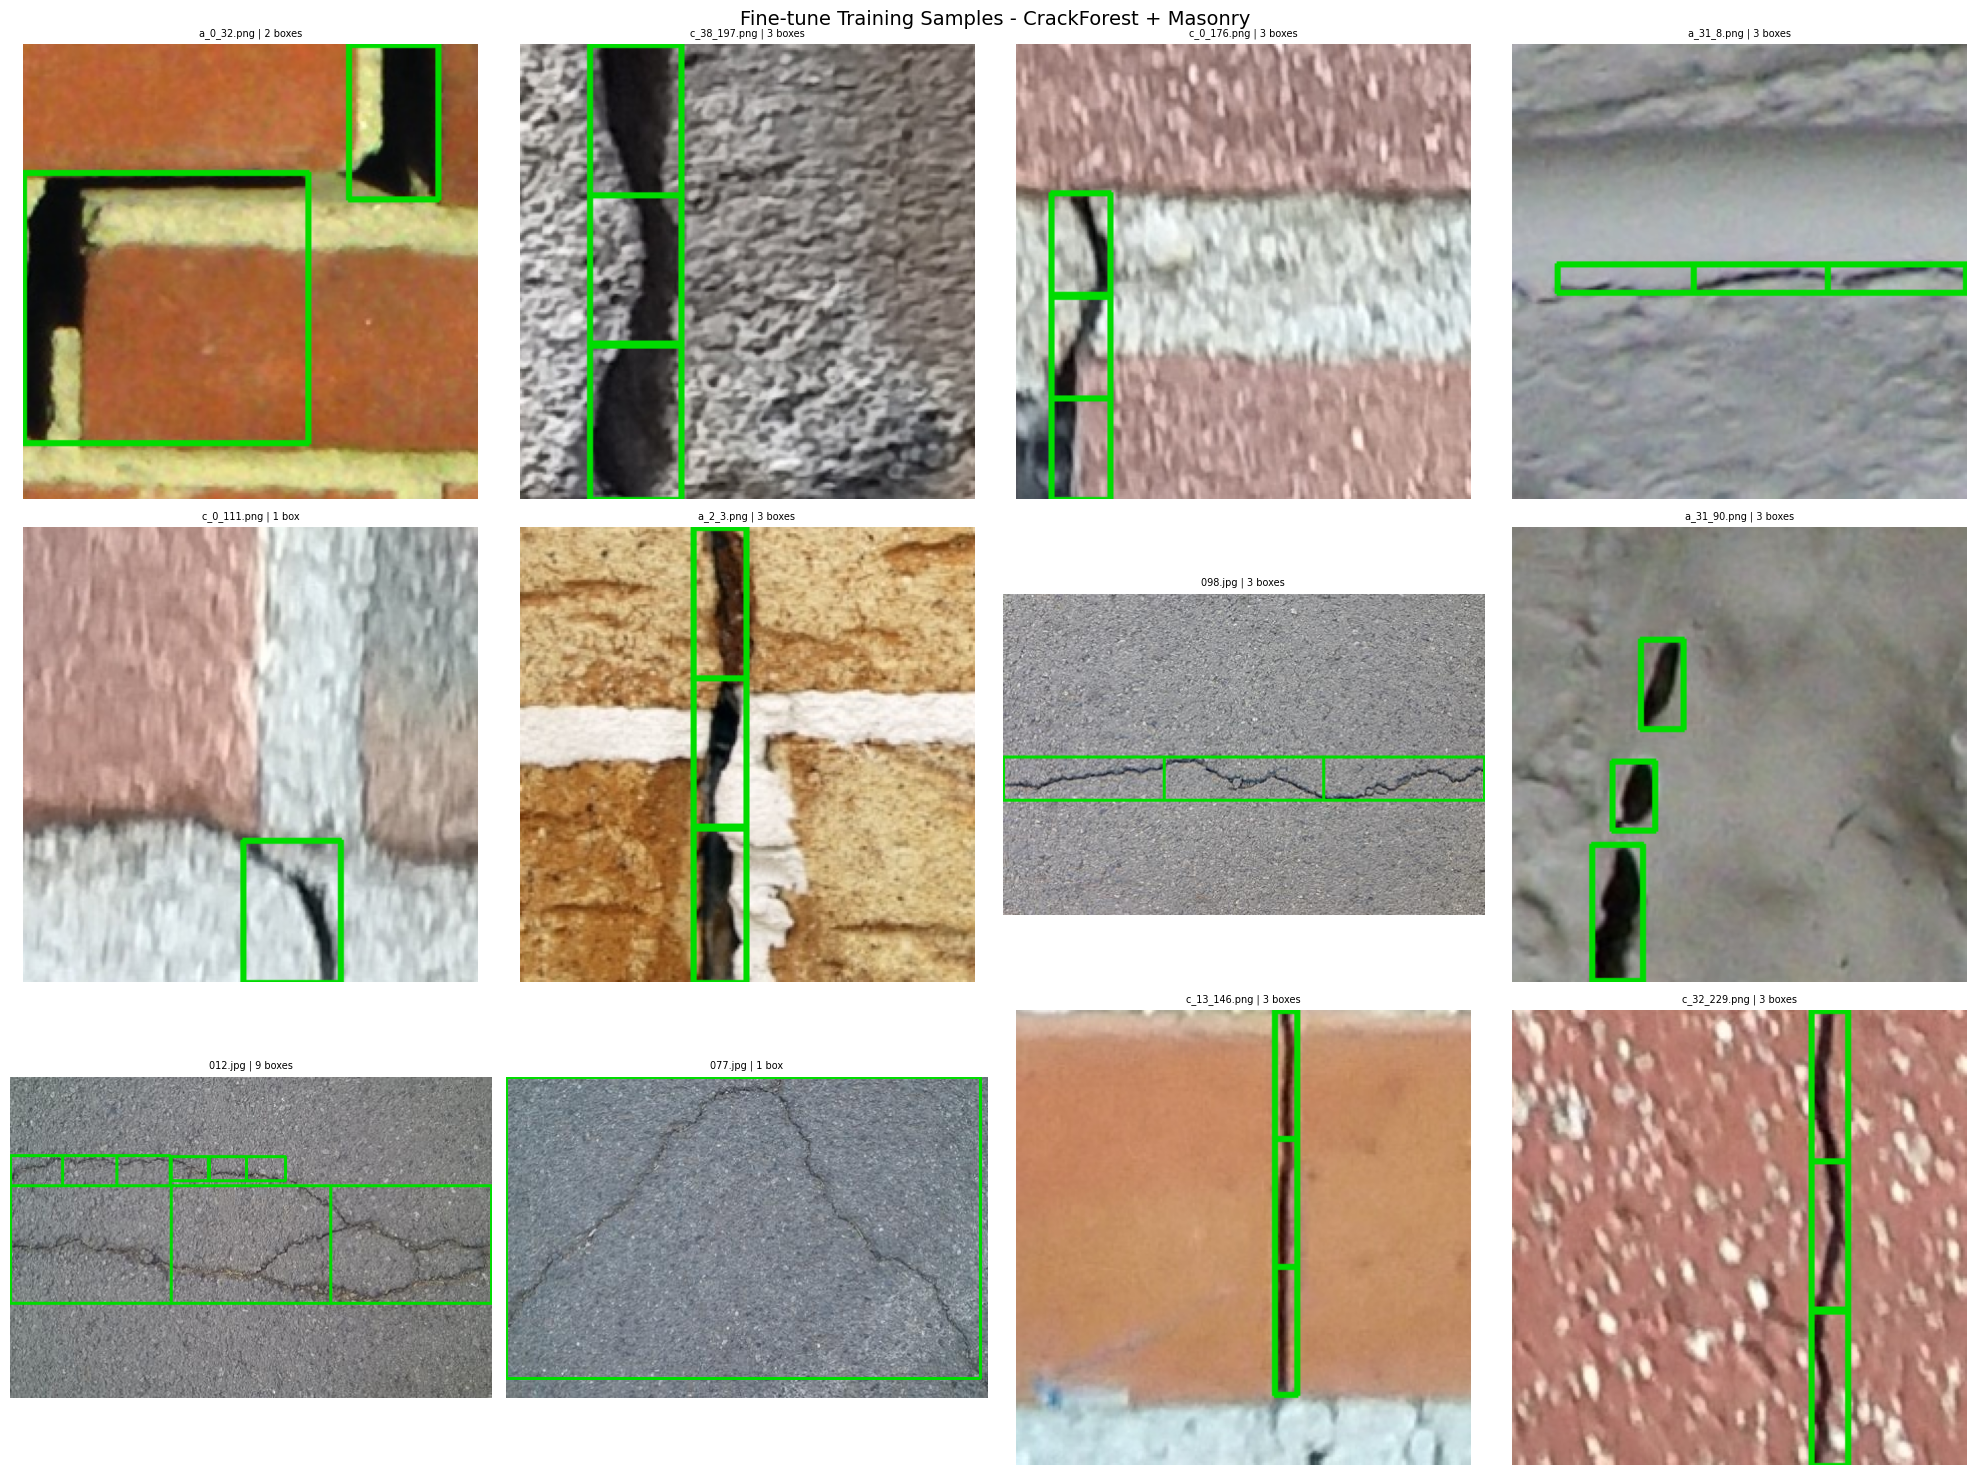

Grid saved. 238 images with boxes total.


In [7]:
import random, cv2
import matplotlib.pyplot as plt

def draw_yolo_boxes(img_path, lbl_path, color=(0, 220, 0), thickness=2):
    raw = cv2.imread(str(img_path))
    if raw is None:
        return None
    img = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl = Path(lbl_path)
    if lbl.exists():
        for line in lbl.read_text().strip().splitlines():
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
            x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    return img

train_img_dir = YOLO_DIR / "train" / "images"
train_lbl_dir = YOLO_DIR / "train" / "labels"
all_train = sorted(train_img_dir.glob("*.*"))
with_boxes = [
    p for p in all_train
    if (train_lbl_dir / (p.stem + ".txt")).exists()
    and (train_lbl_dir / (p.stem + ".txt")).read_text().strip()
]
sample = random.sample(with_boxes, min(12, len(with_boxes)))

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle("Fine-tune Training Samples - CrackForest + Masonry", fontsize=14)
for ax, img_path in zip(axes.flat, sample):
    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    n_boxes = len(lbl_path.read_text().strip().splitlines()) if lbl_path.exists() else 0
    img = draw_yolo_boxes(img_path, lbl_path)
    if img is None:
        ax.axis("off")
        continue
    ax.imshow(img)
    suffix = "es" if n_boxes != 1 else ""
    ax.set_title(img_path.name + " | " + str(n_boxes) + " box" + suffix, fontsize=7)
    ax.axis("off")
for ax in axes.flat[len(sample):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/finetune_training_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grid saved. " + str(len(with_boxes)) + " images with boxes total.")


## 3. Baseline — Before Fine-tuning

In [8]:
from ultralytics import YOLO

base_model = YOLO('/content/base_detector.pt')

print("=== Baseline on fine-tune TEST split ===")
baseline = base_model.val(
    data=str(data_yaml),
    split='test',
    device=0,
    imgsz=640,
    verbose=False,
)
print(f"mAP@50    : {baseline.box.map50:.4f}")
print(f"Precision : {baseline.box.mp:.4f}")
print(f"Recall    : {baseline.box.mr:.4f}")

baseline_map50 = float(baseline.box.map50)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
=== Baseline on fine-tune TEST split ===
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1876.9±645.3 MB/s, size: 53.3 KB)
val: Scanning /content/yolo_finetune/test/labels... 54 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 54/54 2.1Kit/s 0.0s
val: New cache created: /content/yolo_finetune/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.6it/s 2.5s
                   all         54        120      0.303      0.108     0.0876     

## 4. Fine-tuning

In [9]:
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

ft_model = YOLO('/content/base_detector.pt')

results = ft_model.train(
    data=str(data_yaml),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project='/content/runs_ft',
    name='crack_ft',
    exist_ok=True,
    patience=15,
    save=True,
    plots=True,
    seed=42,
    amp=True,
    lr0=0.001,       # lower LR for fine-tuning (10x below default)
    lrf=0.01,
    warmup_epochs=3,
    freeze=10,       # freeze first 10 backbone layers — preserve OmniCrack features
    close_mosaic=10, # disable mosaic last 10 epochs for stability
    verbose=False,
)
print("Fine-tuning complete!")

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_finetune/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/base_detector.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=crack_ft, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

## 5. Evaluation — After Fine-tuning

In [10]:
ft_best = YOLO('/content/runs_ft/crack_ft/weights/best.pt')

print("=== Fine-tuned on TEST split ===")
ft_metrics = ft_best.val(
    data=str(data_yaml),
    split='test',
    device=0,
    imgsz=640,
    verbose=False,
)
print(f"mAP@50    : {ft_metrics.box.map50:.4f}")
print(f"Precision : {ft_metrics.box.mp:.4f}")
print(f"Recall    : {ft_metrics.box.mr:.4f}")

print()
print(f"=== Improvement ===")
delta = float(ft_metrics.box.map50) - baseline_map50
print(f"Before : {baseline_map50:.4f}")
print(f"After  : {ft_metrics.box.map50:.4f}")
print(f"Delta  : {delta:+.4f}  ({delta / (baseline_map50 + 1e-8) * 100:+.1f}%)")

=== Fine-tuned on TEST split ===
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1385.7±641.4 MB/s, size: 70.4 KB)
val: Scanning /content/yolo_finetune/test/labels.cache... 54 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 54/54 20.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.4it/s 1.7s
                   all         54        120      0.281      0.341      0.236      0.105
Speed: 7.2ms preprocess, 10.0ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP@50    : 0.2355
Precision : 0.2806
Recall    : 0.3413

=== Improvement ===
Before : 0.0876
After  : 0.2355
Delta  : +0.1479  (+168.8%)


In [11]:
# Per-source eval: crackforest vs masonry test subsets
import random

ft_best_path = '/content/runs_ft/crack_ft/weights/best.pt'

for source in ['crackforest', 'masonry']:
    src_test = [(p, m) for (p, m), s in zip(test_s, test_src) if s == source]
    if not src_test:
        continue

    src_dir = YOLO_DIR / f'test_{source}'
    (src_dir / 'images').mkdir(parents=True, exist_ok=True)
    (src_dir / 'labels').mkdir(parents=True, exist_ok=True)

    for img_path, mask_path in src_test:
        labels = mask_to_yolo_labels(mask_path, min_area=200)
        (src_dir / 'labels' / f"{img_path.stem}.txt").write_text('\n'.join(labels))
        dst = src_dir / 'images' / img_path.name
        if not dst.exists():
            shutil.copy2(img_path, dst)

    yaml = src_dir / 'data.yaml'
    yaml.write_text(
        f"path: {src_dir}\n"
        f"train: images\nval: images\ntest: images\n"
        f"nc: 1\nnames: ['crack']\n"
    )

    m_base = YOLO('/content/base_detector.pt').val(
        data=str(yaml), split='test', device=0, imgsz=640, verbose=False)
    m_ft   = YOLO(ft_best_path).val(
        data=str(yaml), split='test', device=0, imgsz=640, verbose=False)

    print(f"=== {source.capitalize()} (n={len(src_test)}) ===")
    print(f"  Before : mAP@50={m_base.box.map50:.4f}")
    print(f"  After  : mAP@50={m_ft.box.map50:.4f}  ({m_ft.box.map50 - m_base.box.map50:+.4f})")

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1047.6±232.5 MB/s, size: 31.6 KB)
val: Scanning /content/yolo_finetune/test_crackforest/labels... 18 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18/18 2.0Kit/s 0.0s
val: New cache created: /content/yolo_finetune/test_crackforest/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0it/s 1.0s
                   all         18         38       0.32      0.289      0.181     0.0504
Speed: 7.2ms preprocess, 31.6ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val-3
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (pin

## 6. Visualisations

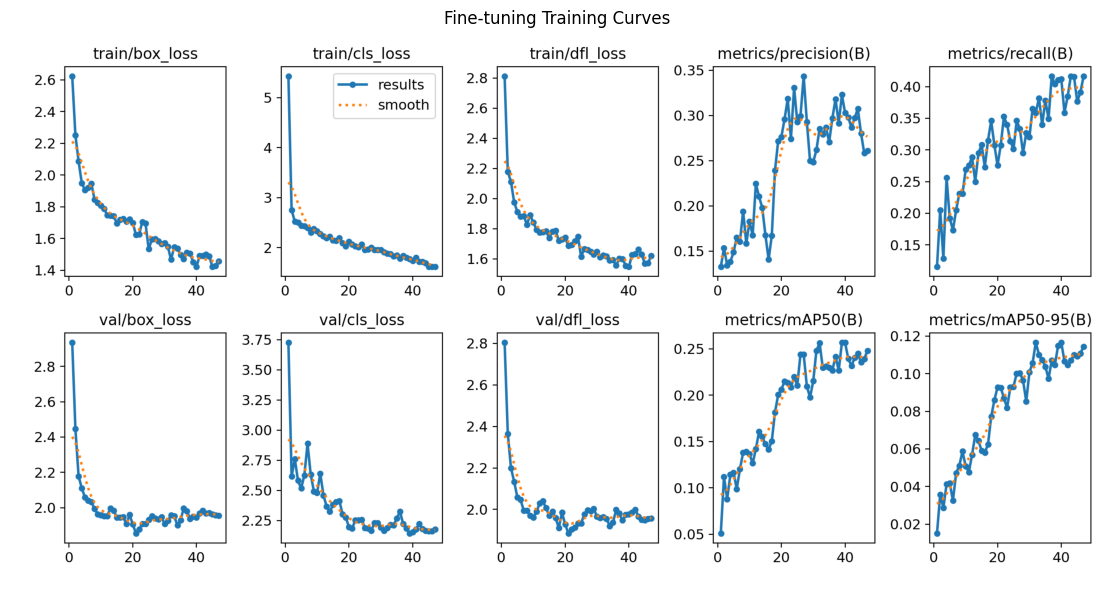

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Training curves from run directory
run_dir = Path('/content/runs_ft/crack_ft')
results_png = run_dir / 'results.png'
if results_png.exists():
    img = mpimg.imread(str(results_png))
    plt.figure(figsize=(14, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Fine-tuning Training Curves', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'ft_training_curves.png', dpi=150)
    plt.show()

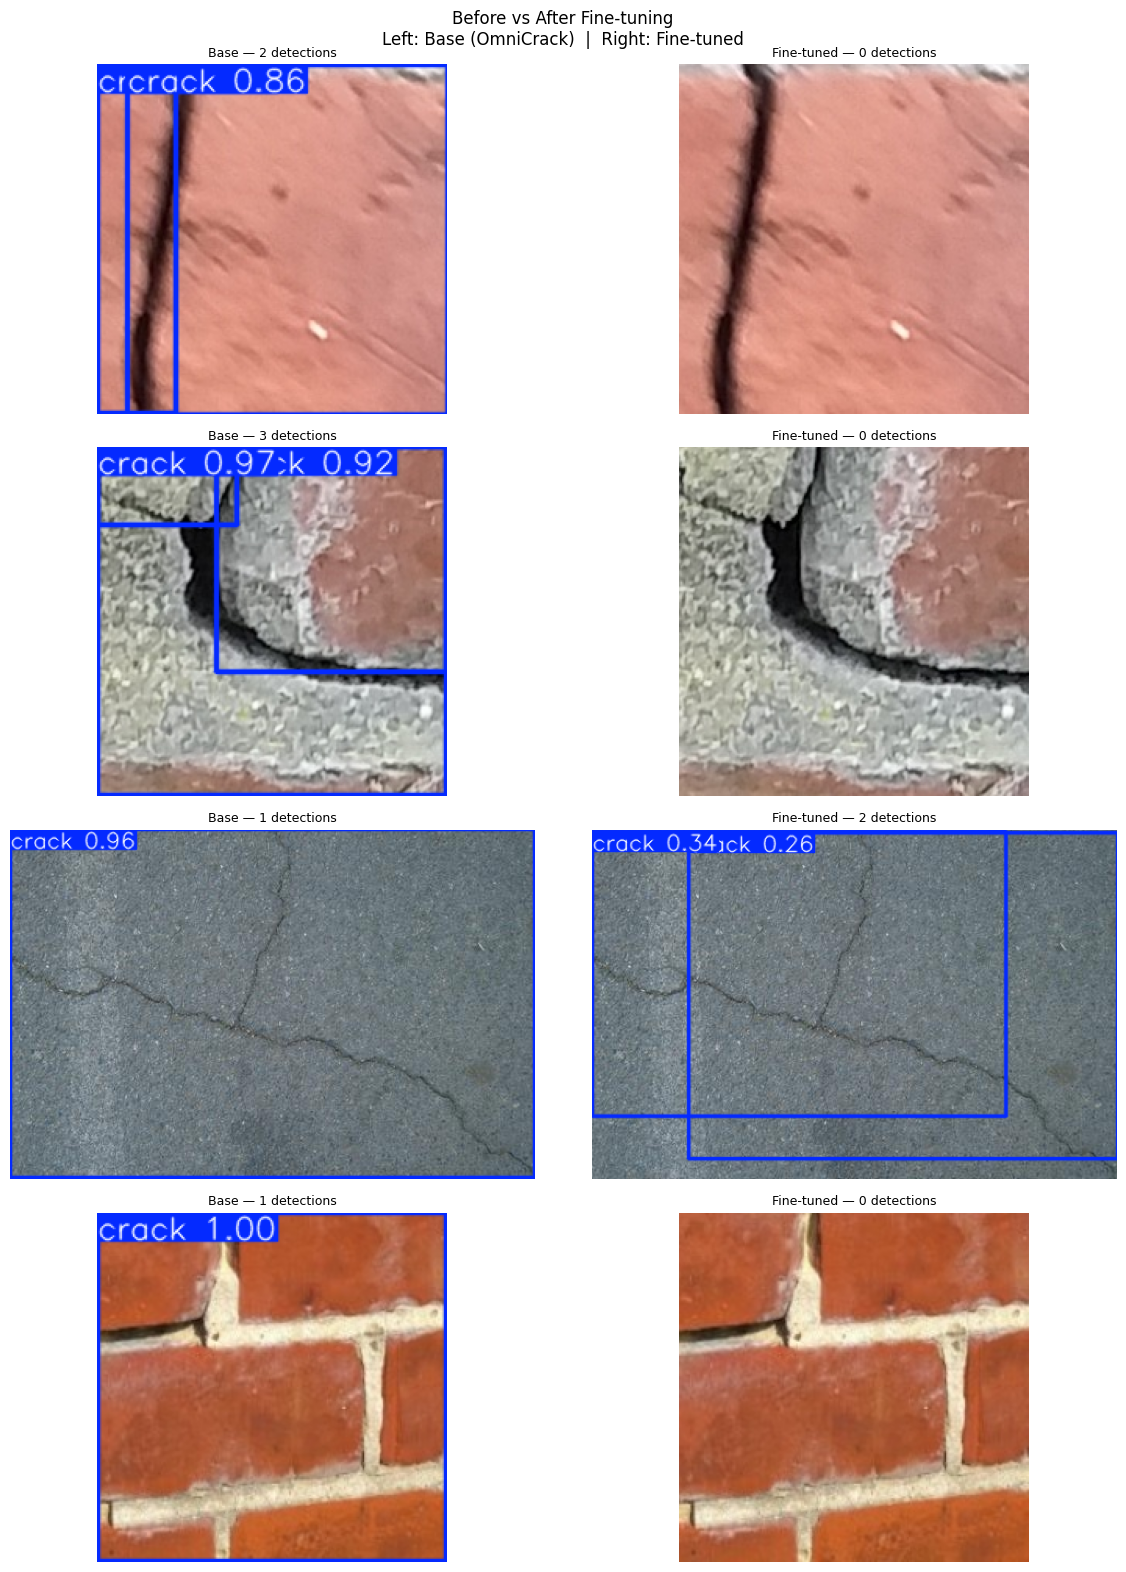

In [13]:
# Before / After prediction comparison
import cv2, random

test_img_dir = YOLO_DIR / 'test' / 'images'
test_imgs    = list(test_img_dir.glob('*.*'))
sample_imgs  = random.sample(test_imgs, min(4, len(test_imgs)))

base_model_cmp = YOLO('/content/base_detector.pt')
ft_model_cmp   = YOLO('/content/runs_ft/crack_ft/weights/best.pt')

fig, axes = plt.subplots(len(sample_imgs), 2, figsize=(12, 4 * len(sample_imgs)))
fig.suptitle('Before vs After Fine-tuning\nLeft: Base (OmniCrack)  |  Right: Fine-tuned',
             fontsize=12)

for row, img_path in enumerate(sample_imgs):
    r_base = base_model_cmp.predict(str(img_path), conf=0.25, verbose=False)[0]
    r_ft   = ft_model_cmp.predict(str(img_path),   conf=0.25, verbose=False)[0]

    axes[row, 0].imshow(cv2.cvtColor(r_base.plot(), cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"Base — {len(r_base.boxes)} detections", fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cv2.cvtColor(r_ft.plot(), cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title(f"Fine-tuned — {len(r_ft.boxes)} detections", fontsize=9)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'ft_before_after.png', dpi=150)
plt.show()

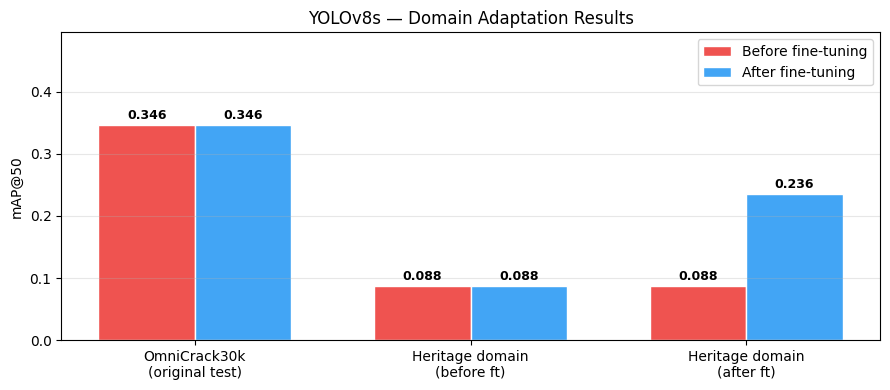

In [14]:
# mAP@50 comparison bar chart
fig, ax = plt.subplots(figsize=(9, 4))

categories   = ['OmniCrack30k\n(original test)', 'Heritage domain\n(before ft)', 'Heritage domain\n(after ft)']
before_maps  = [0.3459, baseline_map50,             baseline_map50]
after_maps   = [0.3459, baseline_map50,             float(ft_metrics.box.map50)]

x     = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, before_maps, width, label='Before fine-tuning',
               color='#EF5350', edgecolor='white')
bars2 = ax.bar(x + width/2, after_maps,  width, label='After fine-tuning',
               color='#42A5F5', edgecolor='white')

ax.set_ylabel('mAP@50')
ax.set_title('YOLOv8s — Domain Adaptation Results')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, max(max(before_maps), max(after_maps)) + 0.15)
ax.legend()
ax.axhline(0.70, color='green', linestyle='--', lw=1.5, label='target 0.70', alpha=0.7)
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'ft_map_comparison.png', dpi=150)
plt.show()

## 7. Save to Drive

In [15]:
DRIVE_FT = DRIVE_DIR / 'checkpoints' / 'detector_ft'
DRIVE_FT.mkdir(parents=True, exist_ok=True)

DRIVE_FT_PLOTS = DRIVE_DIR / 'plots' / 'detector_ft'
DRIVE_FT_PLOTS.mkdir(parents=True, exist_ok=True)

# Checkpoint
best_pt = Path('/content/runs_ft/crack_ft/weights/best.pt')
if best_pt.exists():
    shutil.copy2(best_pt, DRIVE_FT / 'best.pt')

# Plots
for f in sorted(OUT_DIR.glob('*.png')):
    shutil.copy2(f, DRIVE_FT_PLOTS / f.name)
for f in sorted(run_dir.glob('*.png')):
    shutil.copy2(f, DRIVE_FT_PLOTS / f.name)

# Metrics JSON
ft_summary = {
    'baseline_map50':   baseline_map50,
    'finetuned_map50':  float(ft_metrics.box.map50),
    'finetuned_map5095': float(ft_metrics.box.map),
    'precision':        float(ft_metrics.box.mp),
    'recall':           float(ft_metrics.box.mr),
    'delta_map50':      float(ft_metrics.box.map50) - baseline_map50,
    'train_images':     len(train_s),
    'val_images':       len(val_s),
    'test_images':      len(test_s),
    'freeze_layers':    10,
    'epochs':           50,
    'lr0':              0.001,
}
(DRIVE_FT / 'ft_metrics.json').write_text(json.dumps(ft_summary, indent=2))

print("Saved to Drive:")
for f in sorted(DRIVE_FT.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

print(f"\n=== Final Summary ===")
print(f"Base  mAP@50: {baseline_map50:.4f}")
print(f"FT    mAP@50: {float(ft_metrics.box.map50):.4f}")
print(f"Delta       : {float(ft_metrics.box.map50) - baseline_map50:+.4f}")

Saved to Drive:
  best.pt  (22.5 MB)
  ft_metrics.json  (0.0 MB)

=== Final Summary ===
Base  mAP@50: 0.0876
FT    mAP@50: 0.2355
Delta       : +0.1479
